In [1]:
%pip install numpy
%pip install scipy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [49]:
import math
import numpy as np
from scipy.integrate import ode
from matplotlib import pyplot as plt

In [50]:
g = 9.8
EPSILON = 1e-3

def solve_rolling(r: float, m: float, I: float, friction_coefficient: float, alpha: float, 
                  v0: float, w0: float, max_t: float, dt: float = 0.01) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    state_0 = [0, v0, w0]

    gravity = m * g * math.sin(alpha)

    def compute_friction(v: float, w: float) -> float:
        v_contact = v - w * r

        max_friction = friction_coefficient * g * math.cos(alpha)
        stable_friction = min(gravity * (1 - 1 / (I / m / r ** 2 + 1)), max_friction)

        if v_contact > EPSILON:
            return max_friction
        elif v_contact < -EPSILON:
            return -max_friction
        else:
            return stable_friction

    def derivatives(_, state: tuple[float, float, float]):
        _, v, w = state
        friction = compute_friction(v, w)

        derivatives = [
            v,
            gravity - friction,
            friction * r / I
        ]
        return derivatives

    integrator = ode(derivatives)
    integrator.set_initial_value(state_0, 0)
    integrator.set_integrator('dopri5', rtol=1e-6)

    t_values = []
    path_values = []
    v_values = []
    w_values = []
    is_slipping = []
    friction_values = []

    while integrator.successful() and integrator.t < max_t:
        path, v, w = integrator.integrate(integrator.t + dt)
        t_values.append(integrator.t)
        path_values.append(path)
        v_values.append(v)
        w_values.append(w)
        is_slipping.append(abs(v - w * r) > EPSILON)
        friction_values.append(compute_friction(v, w))

    return (np.array(t_values), np.array(path_values), np.array(v_values),
            np.array(w_values), np.array(is_slipping), np.array(friction_values))

In [140]:
def show_analysis(r: float, m: float, I: float, friction_coefficient: float, alpha: float, 
                  v0: float, w0: float, max_t: float, dt: float = 0.01) -> None:
    t, path, v, w, is_slipping, friction = solve_rolling(r, m, I, friction_coefficient, alpha, v0, w0, max_t, dt)


    plt.figure(figsize=(12, 8))

    plt.plot(t, v, label='Скорость центра масс')
    plt.plot(t, w * r, label='Скорость вращения поверхности')

    plt.title('Скорости')
    plt.xlabel('Время, с')
    plt.ylabel('Скорость, м/с')
    plt.legend()
    plt.grid(True)
    plt.show()


    plt.figure(figsize=(12, 8))

    plt.plot(t, friction)

    plt.title('Сила трения')
    plt.xlabel('Время, с')
    plt.ylabel('Сила трения, Н')
    plt.grid(True)


    rotation_energy = I * w ** 2 / 2
    forward_movement_energy = m * v ** 2 / 2
    kinetic_energy = forward_movement_energy + rotation_energy
    potential_energy = - r * g * path * math.sin(alpha)

    plt.figure(figsize=(12, 8))

    plt.plot(t, forward_movement_energy, label='Энергия поступательного движения')
    plt.plot(t, rotation_energy, label='Энергия вращения')
    plt.plot(t, kinetic_energy, label='Кинетическая энергия (вся)')
    plt.plot(t, potential_energy, label='Потенциальная энергия')

    plt.title('Энергия')
    plt.xlabel('Время, с')
    plt.ylabel('Энергия, Дж')
    plt.legend()
    plt.grid(True)


    # plt.figure(figsize=(12, 8))

    # plt.plot(t, I * w)

    # plt.ylim(bottom=0.0)

    # plt.title('Момент импульса')
    # plt.xlabel('Время, с')
    # plt.ylabel('Момент импульса, кг * м ** 2 / с')
    # plt.grid(True)

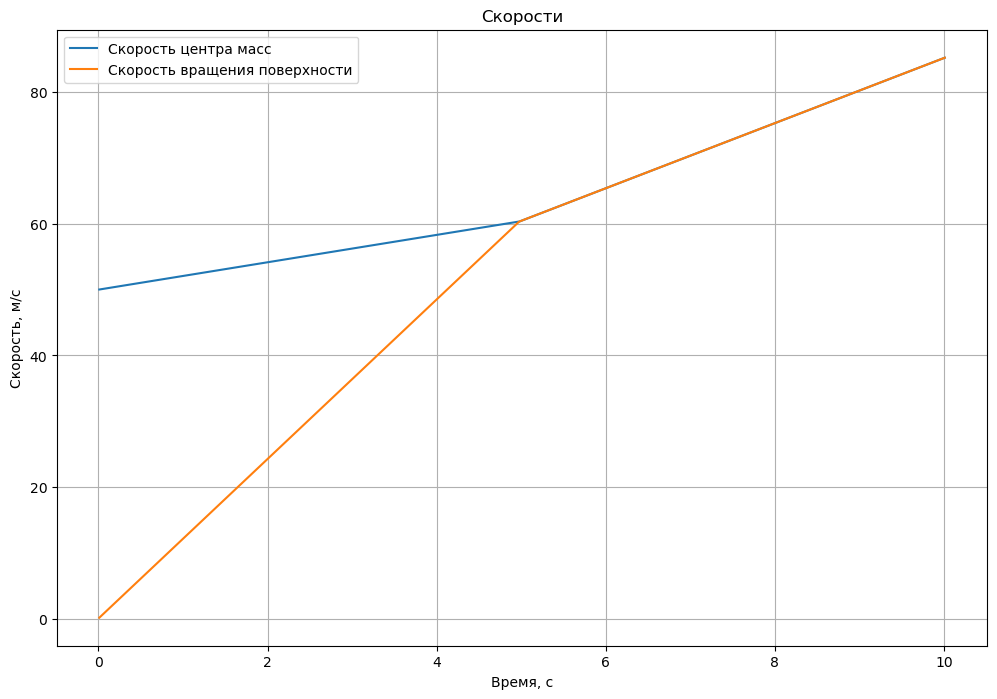

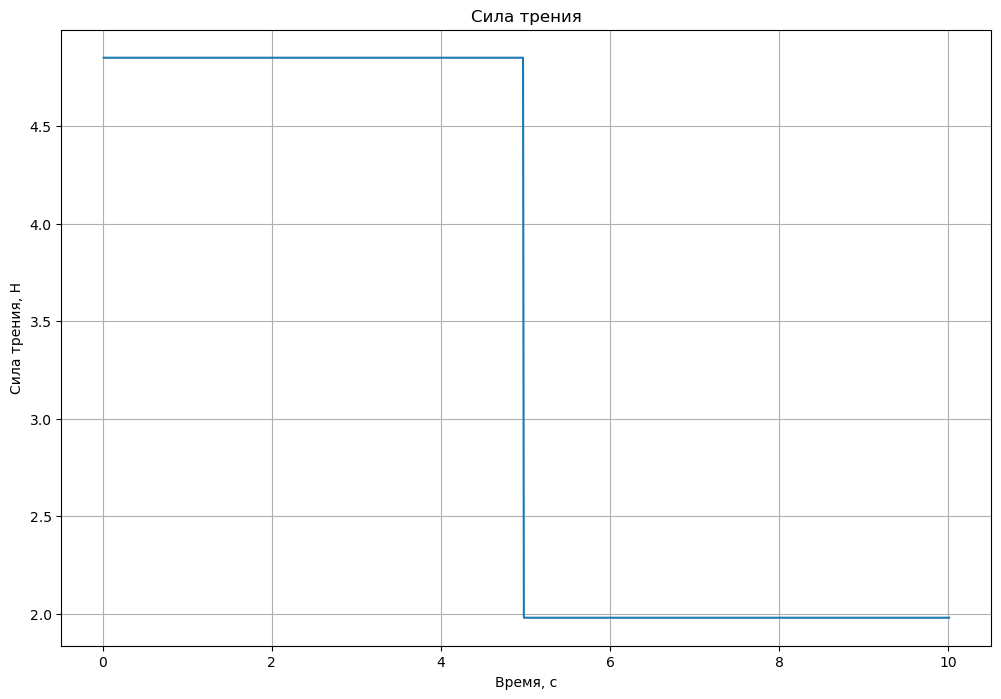

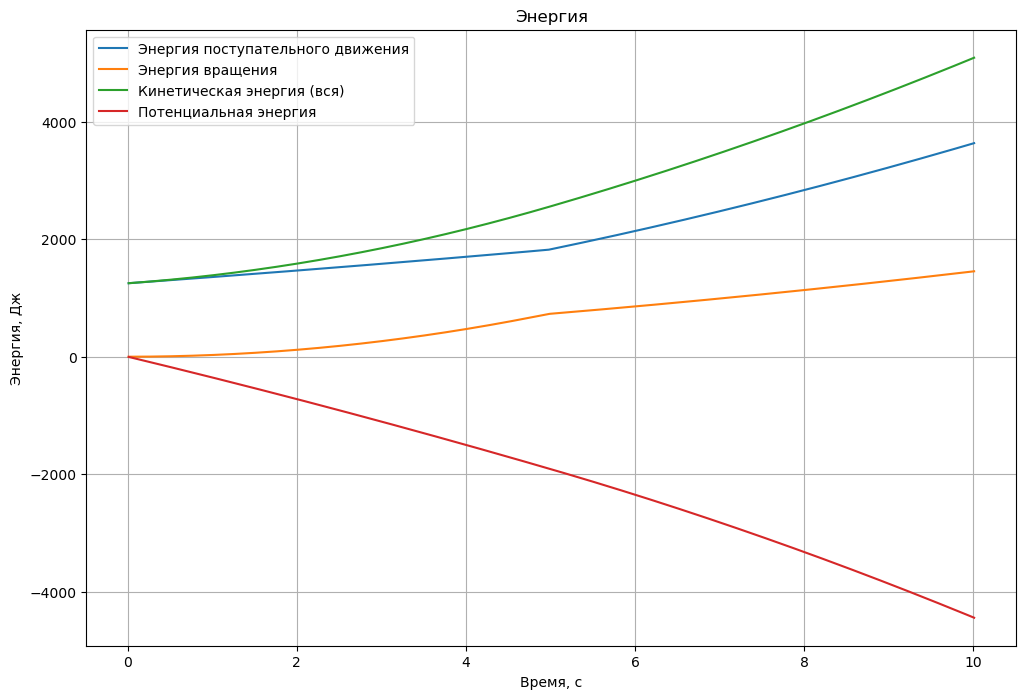

In [141]:
show_analysis(1, 1, 2 / 5, 0.7, math.pi / 4, 50.0, 0.0, 10.0)

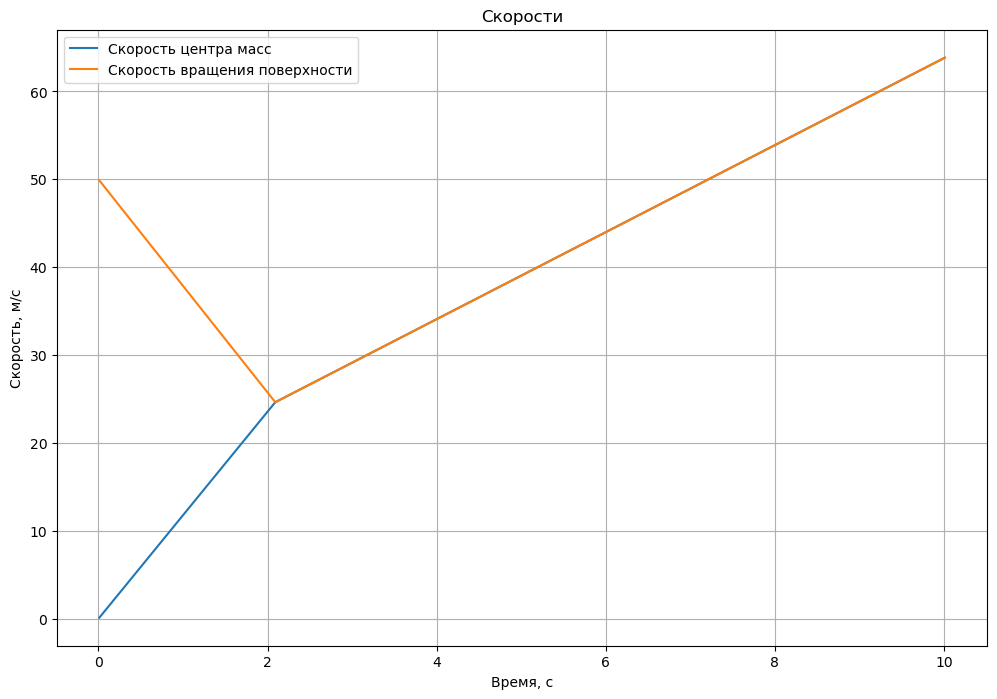

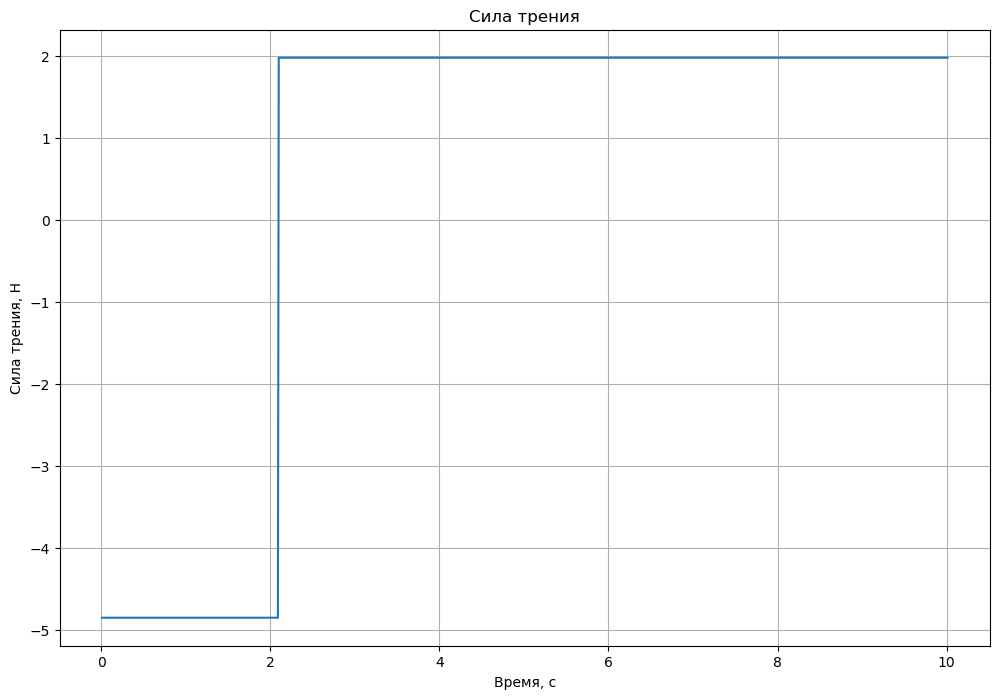

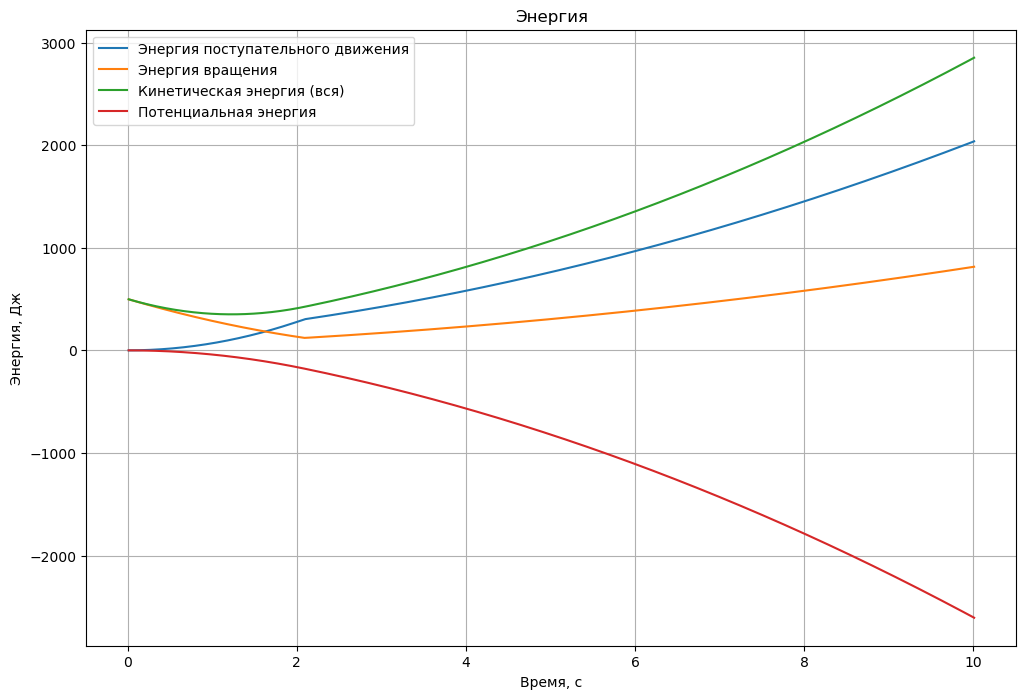

In [142]:
show_analysis(1, 1, 2 / 5, 0.7, math.pi / 4, 0.0, 50.0, 10.0)

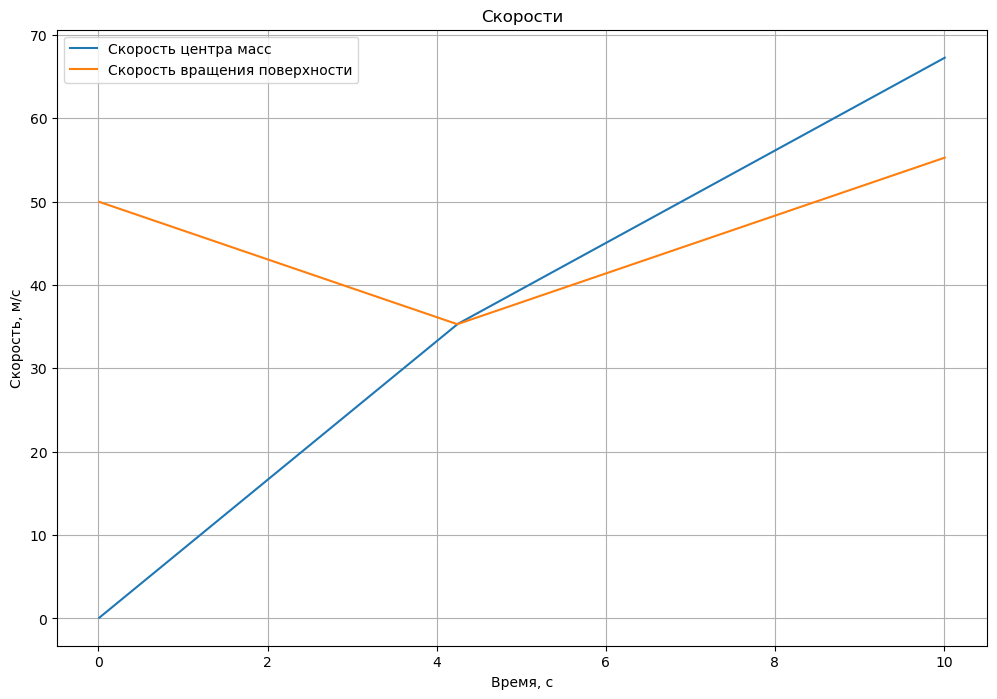

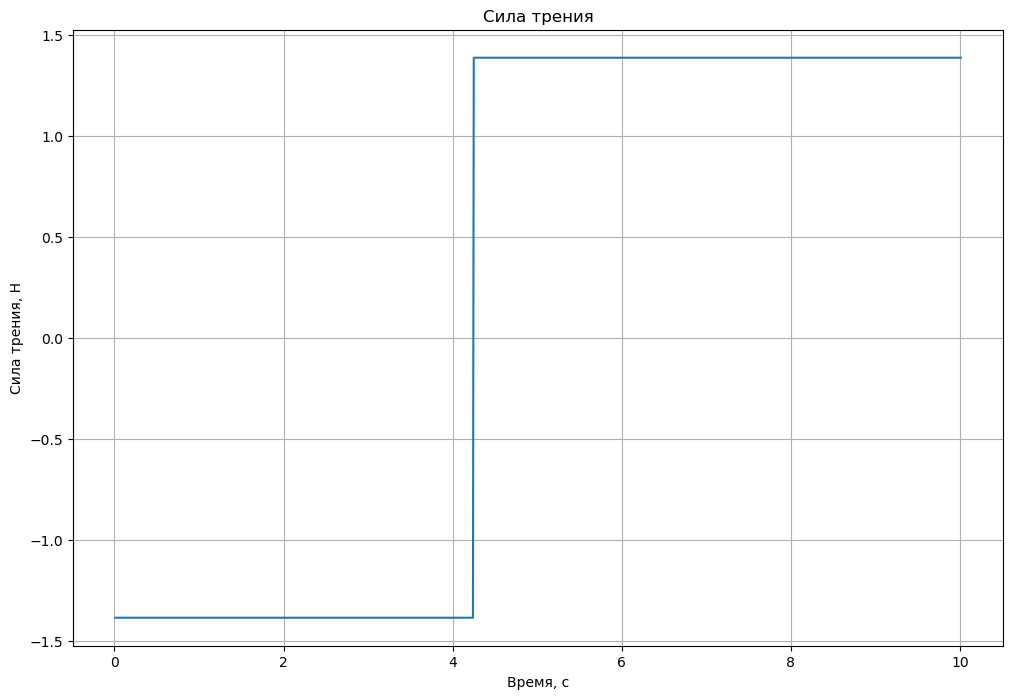

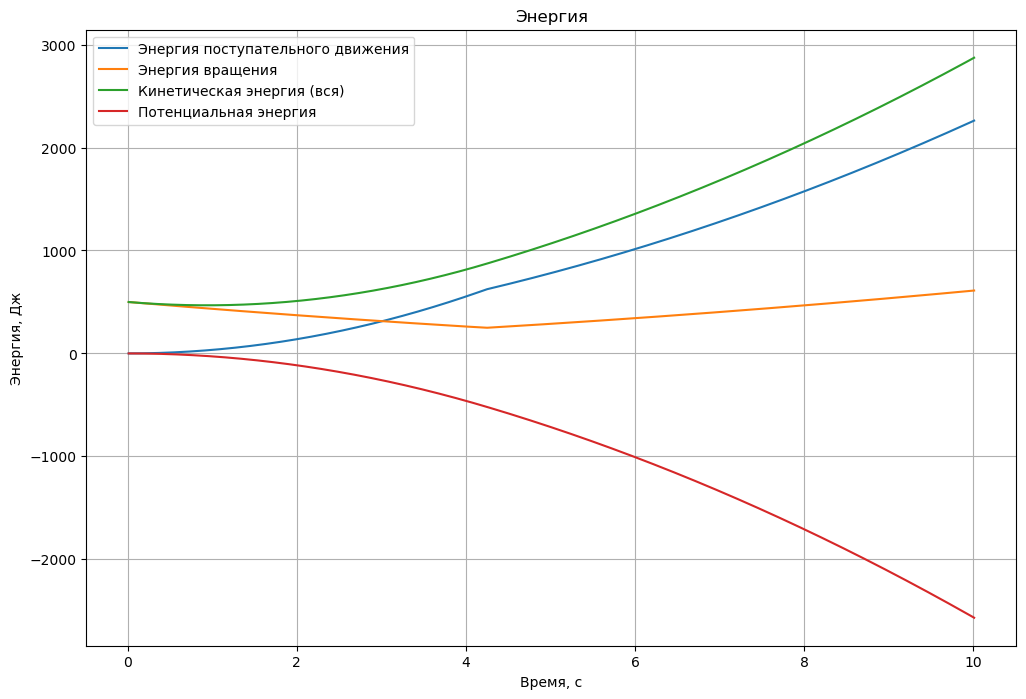

In [143]:
show_analysis(1, 1, 2 / 5, 0.2, math.pi / 4, 0.0, 50.0, 10.0)